In [10]:
from model import Seq2SeqTransformer, FeatureExtractor
import torch
import torch.nn as nn
import torch.optim as optim
from dataloader import DocLayNetDataset
import random

N = 20
num_classes = 11

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# set TOKENIZERS_PARALLELISM=false to avoid warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=3.0, ignore_index=-1):
        super().__init__()
        self.alpha = alpha  # shape: (num_classes,)
        self.gamma = gamma
        self.ignore_index = ignore_index

        self.ce = nn.CrossEntropyLoss(reduction="none", ignore_index=ignore_index)

    def forward(self, logits, targets):
        """
        logits: (N, num_classes)
        targets: (N,)
        """
        ce_loss = self.ce(logits, targets)  # (N,)
        
        valid_mask = (targets != self.ignore_index)
        
        if valid_mask.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        
        ce_loss_valid = ce_loss[valid_mask]
        targets_valid = targets[valid_mask]
        
        pt = torch.exp(-ce_loss_valid)
        
        if self.alpha is not None:
            alpha_t = self.alpha[targets_valid]  # (num_valid,)
            focal_loss = alpha_t * ((1 - pt) ** self.gamma) * ce_loss_valid
        else:
            focal_loss = ((1 - pt) ** self.gamma) * ce_loss_valid
        
        return focal_loss.mean()

dataset = DocLayNetDataset(split="test")
feature_extractor = FeatureExtractor(dataset)
pages_features, pages_targets = feature_extractor.get_page_features()

label_counts = torch.zeros(num_classes, dtype=torch.float32) 
for labels in pages_targets: 
    for lbl in labels: 
        label_counts[lbl] += 1 

class_weights = 1.0 / torch.sqrt(label_counts + 1e-6) 
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(device)

features_and_targets = list(zip(pages_features, pages_targets))

random.shuffle(features_and_targets)
total = len(features_and_targets)
training_data = features_and_targets[:int(0.8 * total)]
validation_data = features_and_targets[int(0.8 * total):]
print(f"Training samples: {len(training_data)}, Validation samples: {len(validation_data)}")

Using device: cuda


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

100%|██████████| 4999/4999 [10:03<00:00,  8.29it/s]


Training samples: 3910, Validation samples: 978


In [11]:
import importlib

import model as model_module
from model import Seq2SeqTransformer

model = Seq2SeqTransformer(input_dim=N, output_dim=num_classes, num_layers=4, num_heads=8, hidden_dim=512).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
# criterion = nn.CrossEntropyLoss(ignore_index=-1).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2.0, ignore_index=-1)
model

/home/patrickz/anaconda3/envs/perception/lib/python3.11/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Seq2SeqTransformer(
  (input_proj): Linear(in_features=20, out_features=512, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=512, out_features=11, bias=True)
)

In [12]:
from tqdm import tqdm
from model import collate_batch
from sklearn.metrics import confusion_matrix, classification_report
import gc

BATCH_SIZE = 8
EPOCHS = 5
EVAL_FREQUENCY = 100  # evaluate every 100 batches
losses = []
accuracies = []

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    j = 0
    
    epoch_losses = []

    for i in tqdm(range(0, len(training_data), BATCH_SIZE)):
        j += 1
        batch_data = training_data[i:i+BATCH_SIZE]
        
        x, y, lengths = collate_batch(batch_data, N)
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        pred = model(x)  # (batch_size, M, num_classes)
        
        pred_flat = pred.view(-1, num_classes)  # (batch_size * M, num_classes)
        y_flat = y.view(-1)  # (batch_size * M)
        
        loss = criterion(pred_flat, y_flat)

        loss_value = loss.item()
        epoch_loss += loss_value
        epoch_losses.append(loss_value)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        del x, y, pred, pred_flat, y_flat, loss

        # evaluate every EVAL_FREQUENCY batches
        if j % EVAL_FREQUENCY == 0:
            print(f"\nEpoch {epoch} | Step {j}/{len(training_data)//BATCH_SIZE} | Loss: {loss_value:.4f}")
            
            # evaluation
            model.eval()
            all_true, all_pred = [], []
            with torch.no_grad():
                for page_features_val, targets_val in tqdm(validation_data, desc="Validating", leave=False):
                    x_val = torch.tensor(page_features_val, dtype=torch.float32).reshape(N, -1).to(device)
                    y_val = torch.tensor(targets_val, dtype=torch.long).to(device)
                    
                    pred_val = model(x_val)
                    _, predicted_val = torch.max(pred_val, dim=1)
                    
                    all_true.extend(y_val.cpu().tolist())
                    all_pred.extend(predicted_val.cpu().tolist())

                    del x_val, y_val, pred_val, predicted_val
            
            cm = confusion_matrix(all_true, all_pred, labels=list(range(num_classes)))
            accuracy = (cm.diagonal().sum()) / cm.sum()
            accuracies.append(accuracy)
            
            print(f"Val Accuracy: {accuracy:.4f}")
            print(f"Confusion matrix:\n{cm}")
            
            del all_true, all_pred, cm
            
            # manual garbage collection
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            gc.collect()

            # switch back to training mode
            model.train()
    
    losses.append(sum(epoch_losses) / len(epoch_losses))

    # summary after each epoch
    print(f"\n=== Epoch {epoch} Summary ===")
    print(f"Avg Loss: {epoch_loss/(len(training_data)//BATCH_SIZE):.4f}")
    if accuracies:
        print(f"Best Accuracy so far: {max(accuracies):.4f}")
        scheduler.step(max(accuracies))
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6e}\n")
    
    # epoch结束后清理
    del epoch_losses
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

print(f"Best Accuracy: {max(accuracies):.4f}")

  0%|          | 0/489 [00:00<?, ?it/s]

 20%|██        | 99/489 [02:12<05:27,  1.19it/s]


Epoch 0 | Step 100/488 | Loss: 0.5228


Val Accuracy: 0.3974
Confusion matrix:
[[ 4274     0     1   687   726     0  9886     0     0     0     0]
 [   32     0     0     8    28     0   361     0     0     0     0]
 [   66     0     0   121   108     0  6907     0     0     0     0]
 [ 3072     0     3   866   779     0 28981     0     0     0     0]
 [  571     0     1   205   310     0  3525     0     0     0     0]
 [    1     0     0     0     7     0   135     0     0     0     0]
 [ 3711     0    12  1226  1544     0 40012     0     1     2     0]
 [   47     0     0    23    39     0  1060     0     0     0     0]
 [   59     0     0    41    48     0  2139     0     0     0     0]
 [   67     0     0    70    48     0  1431     0     0     0     0]
 [   38     0     1    29    41     0  1056     0     0     0     0]]


 41%|████      | 199/489 [03:33<00:26, 10.78it/s]  

...

 82%|████████▏ | 399/489 [00:48<00:08, 11.21it/s]


Epoch 4 | Step 400/488 | Loss: 0.3178


Val Accuracy: 0.4380
Confusion matrix:
[[ 8951     0     0   627   353     0  4916     0     0   727     0]
 [   27     0     3    27     1     0   307     0     0    64     0]
 [    6     0    20   653    12     0  6494     3     0    14     0]
 [ 8173     0    13  5198    15     0 20271     0     0    31     0]
 [  240     0    12   536   211     1  3538     0     1    73     0]
 [    0     0     2     2     0     0   139     0     0     0     0]
 [ 6301     0    89  3760   262     3 35699     6     0   388     0]
 [   25     0    12   110     7     0  1003     1     0     9     2]
 [   44     0    11   146     5     0  2072     1     0     8     0]
 [  167     0     2   144    40     1  1230     2     0    30     0]
 [   29     0     6   101    11     0  1008     1     0     9     0]]


100%|██████████| 489/489 [01:02<00:00,  7.78it/s]



=== Epoch 4 Summary ===
Avg Loss: 0.4027
Best Accuracy so far: 0.4525
Current LR: 1.000000e-05

Best Accuracy: 0.4525


In [9]:
# evaluation after each epoch version
from tqdm import tqdm
from model import collate_batch
from sklearn.metrics import confusion_matrix, classification_report

BATCH_SIZE = 8
EPOCHS = 10
losses = []
accuracies = []

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    j = 0
    
    for i in tqdm(range(0, len(training_data), BATCH_SIZE)):
        j += 1
        batch_data = training_data[i:i+BATCH_SIZE]
        
        x, y, lengths = collate_batch(batch_data, N)
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        pred = model(x)  # (batch_size, M, num_classes)
        
        pred_flat = pred.view(-1, num_classes)  # (batch_size * M, num_classes)
        y_flat = y.view(-1)  # (batch_size * M)
        
        loss = criterion(pred_flat, y_flat)
        epoch_loss += loss.item()
        losses.append(loss.item())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        if (j + 1) % 50 == 0:
            print(f"Epoch {epoch} | Step {j}/{len(training_data)//BATCH_SIZE} | Loss: {loss.item():.4f}")
    
    # evaluate after each epoch
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for page_features_val, targets_val in tqdm(validation_data, desc="Validating"):
            x_val = torch.tensor(page_features_val, dtype=torch.float32).reshape(N, -1).to(device)
            y_val = torch.tensor(targets_val, dtype=torch.long).to(device)
            
            pred_val = model(x_val)
            _, predicted_val = torch.max(pred_val, dim=1)
            
            all_true.extend(y_val.cpu().tolist())
            all_pred.extend(predicted_val.cpu().tolist())
    
    cm = confusion_matrix(all_true, all_pred, labels=list(range(num_classes)))
    accuracy = (cm.diagonal().sum()) / cm.sum()
    accuracies.append(accuracy)
    
    print(f"\n=== Epoch {epoch} Summary ===")
    print(f"Avg Loss: {epoch_loss/(len(training_data)//BATCH_SIZE):.4f}")
    print(f"Val Accuracy: {accuracy:.4f}")
    print(f"Confusion matrix:\n{cm}")
    print(classification_report(all_true, all_pred, labels=list(range(num_classes)), zero_division=0))
    
    scheduler.step(accuracy)
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6e}\n")

print(f"Best Accuracy: {max(accuracies):.4f}")

/home/patrickz/anaconda3/envs/perception/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
  0%|          | 0/489 [00:00<?, ?it/s]

  1%|          | 6/489 [00:16<22:39,  2.82s/it]


KeyboardInterrupt: 

In [4]:
from tqdm import tqdm
from model import collate_batch
BATCH_SIZE = 8
EPOCHS = 1
losses = []
accuracies = []
model = model

for epoch in range(EPOCHS):
    j = 0
    for i in tqdm(range(0, len(training_data), BATCH_SIZE)):
        j += 1
        batch_data = training_data[i:i+BATCH_SIZE]
            
        x, y, lengths = collate_batch(batch_data, N)
        x, y = x.to(device), y.to(device)
            
        optimizer.zero_grad()
        pred = model(x)  # (batch_size, M, num_classes)
            
        pred_flat = pred.view(-1, num_classes)  # (batch_size * M, num_classes)
        y_flat = y.view(-1)  # (batch_size * M)
            
        loss = criterion(pred_flat, y_flat)
        losses.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # accuracy
        if (j + 1) % 50 == 0:
            total = 0
            correct = 0
            for page_features_val, targets_val in validation_data[:100]:
                x_val = torch.tensor(page_features_val, dtype=torch.float32).reshape(N, -1).to(device)
                y_val = torch.tensor(targets_val, dtype=torch.long).to(device)
                with torch.no_grad():
                    pred_val = model(x_val)
                    _, predicted_val = torch.max(pred_val, dim=1)
                    correct_val = (predicted_val == y_val).sum().item()
                    total += y_val.size(0)
                    correct += correct_val
            accuracy = correct / total

            print(f"Iteration {i+1} | Validation Accuracy = {accuracy:.4f}")
    print(f"Epoch {epoch} | Loss = {loss.item():.4f}, Accuracy = {accuracy:.4f}")


# Ignore, loss is empty plot
import matplotlib.pyplot as plt

context_size = 50
smoothed_losses = []
for i in range(len(losses), context_size):
    smoothed_losses.append(sum(losses[i - context_size:i]) / context_size)
    
plt.plot(smoothed_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

  2%|▏         | 1/62 [00:25<25:48, 25.38s/it]


KeyboardInterrupt: 

In [5]:
model

Seq2SeqTransformer(
  (input_proj): Linear(in_features=6, out_features=512, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=512, out_features=11, bias=True)
)

In [6]:
def visualize_tokens(pdf_features, pdf_path, output_path: str, labels: bool = False):
    from reportlab.pdfgen import canvas
    from PyPDF2 import PdfReader, PdfWriter
    import io
    pages = pdf_features.pages
    first_page = pages[0]
    tokens = first_page.tokens

    reader = PdfReader(pdf_path)
    writer = PdfWriter()
    page = reader.pages[0]
    packet = io.BytesIO()
    width, height = page.mediabox.width, page.mediabox.height
    width, height = float(width), float(height)
    can = canvas.Canvas(packet, pagesize=(width, height))
    for token in tokens:
        bounding_box = token.bounding_box
        l, t, r, b = bounding_box.left, bounding_box.top, bounding_box.right, bounding_box.bottom
        x, y, w, h = l, height - t, r - l, t - b
        token_type = token.token_type


        can.rect(x, y, w, h, stroke=1, fill=0)
        can.drawString(x, y + h + 5, str(token_type))
    can.save()
    packet.seek(0)

    overlay_pdf = PdfReader(packet)
    page.merge_page(overlay_pdf.pages[0])
    writer.add_page(page)

    with open(output_path, "wb") as f_out:
        writer.write(f_out)

In [43]:


from dataloader import ModifiedPdfFeatures
test_pdf = "test_pdfs/DEVOLOPMENT_OF_AN_ALGORITHM_TO_DETERMINATE_THE_ORIENTATION_USING_AN_IMU.pdf"
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
pdf_features = ModifiedPdfFeatures.from_pdf_path(test_pdf)
page = pdf_features.pages[0]
max_length = 14

targets = []
feature_rows = []
for token in page.tokens:
    # token ids, padding to max length
    content = token.content
    encoding = tokenizer(content, add_special_tokens=True, return_tensors="pt")
    token_ids = encoding["input_ids"][0].tolist()
    if len(token_ids) < max_length:
        padding_length = max_length - len(token_ids)
        token_ids += [tokenizer.pad_token_id] * padding_length
    else:
        token_ids = token_ids[:max_length]
    
    # font info
    font_id = float(token.font.font_id)
    font_size = float(token.font.font_size)
    font_features = [font_id, font_size]

    # position info
    box = token.bounding_box
    positions = [box.left, box.top, box.right, box.bottom]

    features = token_ids + font_features + positions
    feature_rows.append(features)
    targets.append(token.token_type.get_index())

feature_rows = torch.tensor(feature_rows, dtype=torch.float32).reshape(N, -1).to('mps')

model.eval()
with torch.no_grad():
    predictions = model(feature_rows)
    _, predicted_labels = torch.max(predictions, dim=1)
print("Predicted labels:", predicted_labels.tolist())

visualize_tokens(pdf_features, test_pdf, "output.pdf", labels=True)


Predicted labels: [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]


In [7]:
def compute_confusion_matrix(model, validation_data, num_classes, N):
    import numpy as np

    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

    model.eval()
    with torch.no_grad():
        for page_features_val, targets_val in tqdm(validation_data):
            x_val = torch.tensor(page_features_val, dtype=torch.float32).reshape(N, -1).to('mps')
            y_val = torch.tensor(targets_val, dtype=torch.long).to('mps')
            
            pred_val = model(x_val)
            _, predicted_val = torch.max(pred_val, dim=1)
            
            for true_label, pred_label in zip(y_val.tolist(), predicted_val.tolist()):
                confusion_matrix[true_label][pred_label] += 1

    return confusion_matrix

    """
    print("各类别指标:")
    print(f"{'类别':<8} {'准确率':<10} {'召回率':<10} {'F1分数':<10} {'样本数':<8}")
    print("-" * 50)

    for i in range(num_classes):
        # True Positives
        tp = confusion_matrix[i][i]
        # False Positives
        fp = confusion_matrix[:, i].sum() - tp
        # False Negatives
        fn = confusion_matrix[i, :].sum() - tp
        # True Negatives
        tn = confusion_matrix.sum() - tp - fp - fn
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        support = confusion_matrix[i, :].sum()
        
        print(f"{i:<8} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f} {support:<8}")

    total_correct = np.trace(confusion_matrix)
    total_samples = confusion_matrix.sum()
    overall_accuracy = total_correct / total_samples if total_samples > 0 else 0
    print("-" * 50)
    print(f"总体准确率: {overall_accuracy:.4f}")
    print(f"总样本数: {total_samples}")"""


100%|██████████| 847/847 [01:20<00:00, 10.59it/s]
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Deja

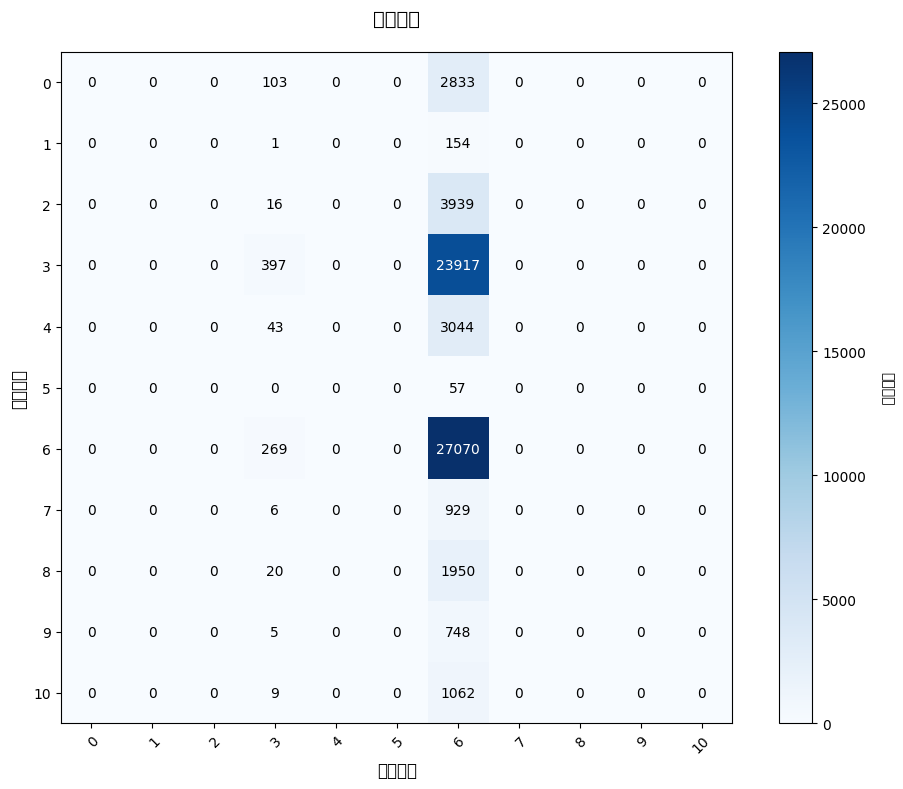

In [9]:
def plot_confusion_matrix(confusion_matrix, num_classes):
    import numpy as np
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(confusion_matrix, cmap='Blues')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('样本数量', rotation=270, labelpad=20)

    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(range(num_classes))
    ax.set_yticklabels(range(num_classes))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(num_classes):
        for j in range(num_classes):
            text = ax.text(j, i, confusion_matrix[i, j],
                        ha="center", va="center", 
                        color="white" if confusion_matrix[i, j] > confusion_matrix.max()/2 else "black")

    ax.set_title("混淆矩阵", fontsize=14, pad=20)
    ax.set_ylabel('真实标签', fontsize=12)
    ax.set_xlabel('预测标签', fontsize=12)
    plt.tight_layout()
    plt.show()

m = compute_confusion_matrix(model=model, validation_data=validation_data, num_classes=num_classes, N =6)
plot_confusion_matrix(m,num_classes)